In [29]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt

# **Paths**

In [20]:
DATA_DIR = "/kaggle/input/indian-currency-real-vs-fake-notes-dataset/data/data"
FEATURE_DIR = "/kaggle/input/curuncy-features/Features"
BASE_MODEL_PATH = "/kaggle/input/best_fake_curruncy_branch1/keras/default/1/best_model.h5"
EMBED_SAVE_DIR = "/kaggle/working/precomputed_features"
os.makedirs(EMBED_SAVE_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

# **Load Base Model for Feature Extraction**

In [21]:
base_model = tf.keras.models.load_model(BASE_MODEL_PATH)
base_model.trainable = False
feature_extractor = Model(inputs=base_model.input, outputs=base_model.layers[-3].output)
feature_extractor.trainable = False
print("Base model loaded and frozen.")

Base model loaded and frozen.


# **Dataset Paths**

In [22]:
def get_image_paths_and_labels(data_dir):
    paths, labels = [], []
    for label_name, label in [("real",1), ("fake",0)]:
        folder = os.path.join(data_dir, label_name)
        for subdir in os.listdir(folder):
            subfolder = os.path.join(folder, subdir)
            for file in os.listdir(subfolder):
                paths.append(os.path.join(subfolder, file))
                labels.append(label)
    return paths, np.array(labels)

all_paths, all_labels = get_image_paths_and_labels(DATA_DIR)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels
)
print("Dataset paths ready:", len(X_train_paths), len(X_val_paths))

Dataset paths ready: 5956 1489


# **Precompute feature embeddings**

In [23]:
MAX_FEATURES = max(len(os.listdir(os.path.join(FEATURE_DIR, note))) 
                   for note in os.listdir(FEATURE_DIR) 
                   if os.path.isdir(os.path.join(FEATURE_DIR, note)))
print("Global MAX_FEATURES per note:", MAX_FEATURES)

for note_name in os.listdir(FEATURE_DIR):
    note_path = os.path.join(FEATURE_DIR, note_name)
    if not os.path.isdir(note_path):
        continue
    
    feature_imgs = []
    for f in os.listdir(note_path):
        f_img = cv2.imread(os.path.join(note_path, f))
        if f_img is not None:
            f_img = cv2.cvtColor(f_img, cv2.COLOR_BGR2RGB)
            f_img = cv2.resize(f_img, IMG_SIZE)
            feature_imgs.append(f_img / 255.0)
    
    # Pad to MAX_FEATURES
    while len(feature_imgs) < MAX_FEATURES:
        feature_imgs.append(np.zeros((*IMG_SIZE,3), dtype=np.float32))
    
    feature_imgs = np.array(feature_imgs[:MAX_FEATURES], dtype=np.float32)
    
    # Predict embeddings
    emb = feature_extractor.predict(feature_imgs, batch_size=16, verbose=0)
    emb_mean = emb.mean(axis=0)
    
    # Save embedding
    np.save(os.path.join(EMBED_SAVE_DIR, note_name + ".npy"), emb_mean)

print("✅ All feature embeddings precomputed!")

Global MAX_FEATURES per note: 258


I0000 00:00:1760626532.067712     100 service.cc:148] XLA service 0x79987c96d940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760626532.070465     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760626532.070489     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760626532.561648     100 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1760626536.060775     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


✅ All feature embeddings precomputed!


# **Generator** 

In [24]:
class TwoBranchEmbeddingGenerator(Sequence):
    def __init__(self, img_paths, labels, embed_dir, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True):
        self.img_paths = img_paths
        self.labels = labels
        self.embed_dir = embed_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.img_paths))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.img_paths)/self.batch_size))
    
    def __getitem__(self, idx):
        batch_indexes = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_img_paths = [self.img_paths[i] for i in batch_indexes]
        batch_labels = np.array([self.labels[i] for i in batch_indexes], dtype=np.float32)
        
        batch_images = np.zeros((len(batch_img_paths), *self.img_size,3), dtype=np.float32)
        batch_features = []
        
        for i, img_path in enumerate(batch_img_paths):
            # Main image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            batch_images[i] = img / 255.0
            
            # Precomputed embedding
            note_name = os.path.splitext(os.path.basename(img_path))[0]
            emb_path = os.path.join(self.embed_dir, note_name + ".npy")
            if os.path.exists(emb_path):
                emb = np.load(emb_path)
            else:
                emb = np.zeros((feature_extractor.output_shape[1],), dtype=np.float32)
            batch_features.append(emb)
        
        batch_features = np.array(batch_features, dtype=np.float32)
        return (batch_images, batch_features), batch_labels
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# **Create Generators**

In [25]:
train_gen = TwoBranchEmbeddingGenerator(X_train_paths, y_train, EMBED_SAVE_DIR, batch_size=BATCH_SIZE)
val_gen   = TwoBranchEmbeddingGenerator(X_val_paths, y_val, EMBED_SAVE_DIR, batch_size=BATCH_SIZE, shuffle=False)

# **Two-Branch Model**

In [26]:
# Image branch
image_input = Input(shape=(*IMG_SIZE,3))
base_cnn = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)
base_cnn.trainable = False
x1 = GlobalAveragePooling2D()(base_cnn.output)
x1 = Dense(256, activation='relu')(x1)
x1 = Dropout(0.4)(x1)

# Feature branch
feature_input = Input(shape=(feature_extractor.output_shape[1],))
x2 = Dense(128, activation='relu')(feature_input)
x2 = Dropout(0.3)(x2)

# Combine branches
combined = Concatenate()([x1, x2])
x = Dense(128, activation='relu')(combined)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

two_branch_model = Model(inputs=[image_input, feature_input], outputs=output)
two_branch_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
two_branch_model.summary()

/tmp/ipykernel_37/4114493656.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,651,841 (10.12 MB)

 Trainable params: 393,857 (1.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Callbacks** 

In [27]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2),
    ModelCheckpoint("best_two_branch_model.keras", save_best_only=True)
]

# **Train**

In [28]:
history = two_branch_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 365s 474ms/step - accuracy: 0.9049 - loss: 0.2498 - val_accuracy: 0.9711 - val_loss: 0.0808 - learning_rate: 0.0010
Epoch 2/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 276s 371ms/step - accuracy: 0.9640 - loss: 0.0840 - val_accuracy: 0.9758 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 3/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 258s 346ms/step - accuracy: 0.9703 - loss: 0.0747 - val_accuracy: 0.9812 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 4/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 257s 345ms/step - accuracy: 0.9790 - loss: 0.0583 - val_accuracy: 0.9792 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 5/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 272s 366ms/step - accuracy: 0.9809 - loss: 0.0507 - val_accuracy: 0.9812 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 6/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 233s 313ms/step - accuracy: 0.9888 - loss: 0.0303 - val_accuracy: 0.9852 - val_loss: 0.0481 - learning_rate: 2.0000e-04
Epoch 7/15
745/745 ━━━━━━━━━━━━━━━━━━━━ 255s 343ms/step - ac

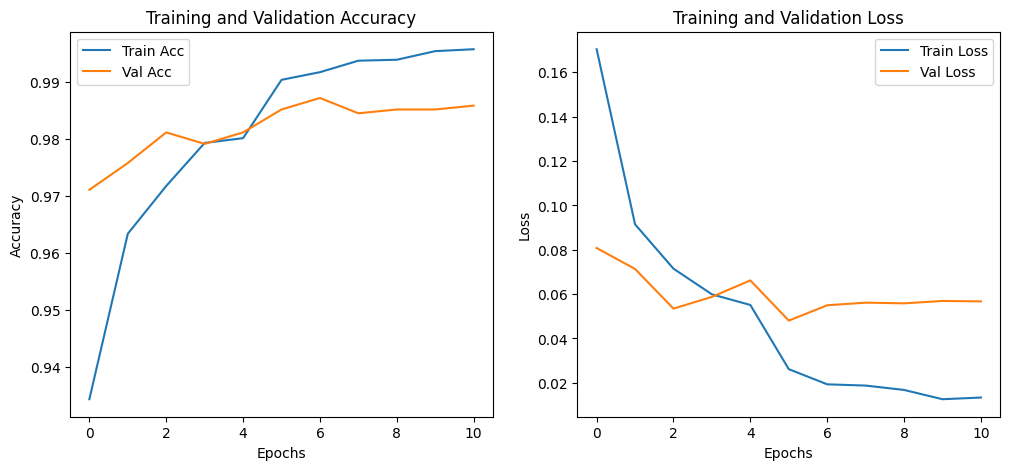

In [30]:
# Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()